# Where safety lives inside three Qwen3-4B models

**Causal depth x site grid, re-run on the stored per-item outcomes of the GPU experiment.**

The original artifact (`method.py` + `src/`) ran, on an NVIDIA L4, a pre-registered causal grid over
three checkpoints — `Qwen/Qwen3-4B` (*instruct*), its safety-finetuned sibling (*SafeRL*) and the
community-uncensored `mlabonne/Qwen3-4B-abliterated`. At each of 6 depth bands (sixths of the 36
layers) and 3 sites it projected out, from the residual stream, either the model's **own request axis
`F`** or the **XSTest benign-twin axis `N6`**, against matched-displacement random controls, and
measured what changed.

This notebook keeps the **analysis half of that pipeline verbatim** (`src/stats.py`'s paired
bootstrap / sign-flip / Holm machinery and `src/analyze.py`'s `causal_cell` + `apply_holm_and_causal`)
and feeds it the **per-item outcome vectors the GPU run wrote to `out/cells/`**. No model is loaded:
the 4B forward passes are already done, their per-row readouts are in `mini_demo_data.json`, and the
statistics are recomputed here from scratch.

**What the demo reproduces**

1. **Site P, forward-only readouts.** Projecting out `F` at the deep bands B4-B6 moves the model's
   first-token refusal-onset mass by several nats — the registered F1 result.
2. **The judged outcome does not follow.** The same cells leave *judged* refusal of harmful requests
   unchanged (0 CAUSAL cells), while the keyword proxy reports refusal collapsing. The model rewords
   its refusal; a text-level proxy calls that a safety failure.
3. **Activation-level model comparison.** Per-layer projections of the residual stream onto
   `[F, N6, F_perpU]` for all three checkpoints, plus the cross-model direction cosines: instruct and
   SafeRL share the axis (cos >= 0.84 per band), while the abliterated checkpoint is identical in
   B1-B3 and **rotated from B4 on** (cos F ~ 0.3, cos N6 ~ 0.02).

Scale knobs live in the **Config** cell; they are set to the original registered values when those fit
the runtime budget.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy, matplotlib — pre-installed on Colab, install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The import block of `src/stats.py`, plus `matplotlib` for the figures at the end.

In [2]:
from __future__ import annotations

import warnings
from typing import Optional

import numpy as np
from scipy.stats import binomtest, norm

import json
import matplotlib.pyplot as plt

## Data loading

`mini_demo_data.json` is the curated subset of the run's own outputs: the site-P arm-0 baseline, 20
`(band, arm)` cells with their per-item `RD` / `T1ref` vectors and matched random-control draws, the
published judged-outcome summaries for the same cells, the three-model activation profiles and the
cross-model direction cosines.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-f8532e-safety-only-checks-output-when-warned/main/round-4/experiment-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

meta = data["metadata"]
print(meta["title"])
print("source:", meta["source_artifact"])
print("site:", meta["site"], "| bands:", meta["bands"], "| arms:", meta["arms"])
print("items:", len(meta["items"]), "(", sum(meta["is_harm"]), "harmful /",
      len(meta["is_harm"]) - sum(meta["is_harm"]), "hard-benign )")
print("cells in demo subset:", len(data["examples"]))
for k, v in meta["outcomes"].items():
    print(f"  {k}: {v}")

Where safety lives inside three Qwen3-4B models - site-P causal grid (demo subset)
source: gen_art_experiment_2 (iter 4, run_YqmEFECOIR3D)
site: P (last prompt token) | bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6'] | arms: ['F', 'N6', 'N6perp', 'POS']
items: 96 ( 48 harmful / 48 hard-benign )
cells in demo subset: 20
  RD: first-token refusal-direction logit gap (forward-only readout, nats)
  T1ref: token-1 refusal-onset indicator (forward-only readout)


## Config

Everything tunable in one place. `B_BOOTSTRAP = 2000`, `N_PERM = 10000` and `SEED = 0` are the
**original registered values** from `src/stats.py` / `src/analyze.py`; they fit the runtime budget
because the heavy part (the 4B forward passes) is already done.

To shrink the demo further, drop `B_BOOTSTRAP` to 200 and `N_PERM` to 1000, or cut `BANDS` / `ARMS`.

In [5]:
# --- statistics (original registered values from src/stats.py / src/analyze.py) ---
B_BOOTSTRAP = 2000      # percentile-bootstrap resamples per effect   (original: 2000)
N_PERM      = 10000     # sign-flip permutations per p-value          (original: 10000)
ALPHA       = 0.05      # two-sided level                             (original: 0.05)
SEED        = 0         # analyze.py SEED                             (original: 0)

# --- grid extent ---
BANDS    = ["B1", "B2", "B3", "B4", "B5", "B6"]   # depth bands = sixths of the 36 layers
ARMS     = ["F", "N6", "N6perp", "POS"]           # projection-out arms + the POS positive control
OUTCOMES = ["RD", "T1ref"]                        # forward-only readouts stored per item
SPLITS   = ["harm", "hb"]                         # harmful probes / hard-benign probes

## The statistics kernel (verbatim from `src/stats.py`)

`paired_effect` is the single contrast primitive of the whole study: the per-item difference between a
treated arm and a reference (either arm 0 or the mean over the matched random-control draws), with a
percentile bootstrap CI and a two-sided sign-flip permutation p-value. `holm` is the step-down
family-wise correction applied across the 6 bands of a family; `empirical_p` places the observed effect
inside the envelope of the random-control draws.

The only edit is `n_perm=N_PERM` / `B=B_BOOTSTRAP` wired to the config cell.

In [6]:
_Z80 = 0.8416212335729143  # Phi^-1(0.9), power = 0.80
_Z95 = 1.959963984540054   # Phi^-1(0.975), alpha = 0.05 (two-sided)


def _finite1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    return x[np.isfinite(x)]


def _bootstrap_means(x: np.ndarray, B: int, seed: int, max_elems: int = 20_000_000) -> np.ndarray:
    """Vectorised percentile-bootstrap: means of B resamples (with replacement) of x."""
    n = x.size
    if n == 0 or B <= 0:
        return np.full(max(B, 0), np.nan)
    rng = np.random.default_rng(seed)
    out = np.empty(B, dtype=float)
    chunk = max(1, min(B, max_elems // max(1, n)))
    start = 0
    while start < B:
        end = min(B, start + chunk)
        idx = rng.integers(0, n, size=(end - start, n))
        out[start:end] = x[idx].mean(axis=1)
        start = end
    return out


def _signflip_p(diff: np.ndarray, seed: int, n_perm: int = 10000, chunk_size: int = 2000) -> float:
    """Two-sided sign-flip permutation p-value on per-item differences `diff`."""
    n = diff.size
    if n == 0:
        return float("nan")
    if np.all(diff == 0):
        return 1.0
    obs = abs(float(diff.mean()))
    rng = np.random.default_rng(seed)
    count = 0
    start = 0
    while start < n_perm:
        end = min(n_perm, start + chunk_size)
        b = end - start
        signs = rng.integers(0, 2, size=(b, n)).astype(np.int8) * 2 - 1
        perm_means = (diff[None, :] * signs).mean(axis=1)
        count += int(np.sum(np.abs(perm_means) >= obs))
        start = end
    return (1.0 + count) / (1.0 + n_perm)


def bootstrap_ci_at(diff: np.ndarray, level_alpha: float, B: int = 2000, seed: int = 0):
    """Percentile bootstrap CI of the mean of per-item differences `diff`, at `level_alpha`."""
    d = _finite1d(diff)
    if d.size == 0:
        return (float("nan"), float("nan"))
    means = _bootstrap_means(d, B, seed)
    lo, hi = np.percentile(means, [100.0 * level_alpha / 2.0, 100.0 * (1.0 - level_alpha / 2.0)])
    return (float(lo), float(hi))


def paired_effect(
    y_a: np.ndarray,
    y_b: Optional[np.ndarray] = None,
    *,
    y_b_draws: Optional[np.ndarray] = None,
    B: int = 2000,
    seed: int = 0,
    alpha: float = 0.05,
) -> dict:
    """Paired per-item effect of y_a vs. a reference, with bootstrap CI and sign-flip p.

    Effect = mean_i[y_a,i - ref_i]. ref_i = y_b[i], or, if `y_b_draws` (shape
    [K, n]) is given instead of `y_b`, ref_i = nanmean over the K draws of
    y_b_draws[:, i] (an item whose draws are all NaN is dropped). NaNs are
    then dropped pairwise between y_a and ref.

    Returns
    -------
    dict with keys: effect, ci_lo, ci_hi (percentile bootstrap over items),
    p_signflip (two-sided sign-flip permutation test, 10000 flips), n,
    sd_diff, mde_80 (paired MDE at alpha=0.05, power=0.8).
    """
    y_a = np.asarray(y_a, dtype=float).reshape(-1)
    if y_b_draws is not None:
        draws = np.asarray(y_b_draws, dtype=float)
        if draws.ndim == 1:
            draws = draws[None, :]
        with np.errstate(invalid="ignore"), warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Mean of empty slice")
            all_nan = np.all(np.isnan(draws), axis=0)
            ref = np.where(all_nan, np.nan, np.nanmean(draws, axis=0))
    else:
        ref = np.asarray(y_b, dtype=float).reshape(-1)

    mask = np.isfinite(y_a) & np.isfinite(ref)
    diff = y_a[mask] - ref[mask]
    n = int(diff.size)

    if n == 0:
        return {
            "effect": float("nan"),
            "ci_lo": float("nan"),
            "ci_hi": float("nan"),
            "p_signflip": float("nan"),
            "n": 0,
            "sd_diff": float("nan"),
            "mde_80": float("nan"),
        }

    effect = float(diff.mean())
    ci_lo, ci_hi = bootstrap_ci_at(diff, alpha, B=B, seed=seed)
    p_signflip = _signflip_p(diff, seed=seed, n_perm=N_PERM)   # notebook: n_perm from the config cell
    sd_diff = float(diff.std(ddof=1)) if n > 1 else float("nan")
    mde_80 = float((_Z95 + _Z80) * sd_diff / np.sqrt(n)) if n > 1 else float("nan")

    return {
        "effect": effect,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "p_signflip": p_signflip,
        "n": n,
        "sd_diff": sd_diff,
        "mde_80": mde_80,
    }


def holm(pvals: list) -> list:
    """Holm step-down adjusted p-values. Monotone non-decreasing, capped at 1.

    NaN-safe: NaN entries stay NaN and are excluded from the family size m.
    """
    p = np.asarray(pvals, dtype=float)
    finite_mask = np.isfinite(p)
    m = int(finite_mask.sum())
    out = np.full(p.shape, np.nan, dtype=float)
    if m == 0:
        return out.tolist()

    finite_idx = np.where(finite_mask)[0]
    finite_p = p[finite_idx]
    order = np.argsort(finite_p, kind="mergesort")  # ascending
    sorted_p = finite_p[order]
    multipliers = np.arange(m, 0, -1, dtype=float)  # m, m-1, ..., 1
    adj_sorted = np.minimum(sorted_p * multipliers, 1.0)
    adj_sorted = np.maximum.accumulate(adj_sorted)  # enforce monotonicity

    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    out[finite_idx] = adj
    return out.tolist()


def empirical_p(effect_f: float, effects_r: np.ndarray) -> float:
    """One-sided empirical p-value of `effect_f` against a null draw pool `effects_r`."""
    r = _finite1d(np.asarray(effects_r, dtype=float))
    K = int(r.size)
    if K == 0:
        return float("nan")
    if effect_f >= 0:
        count = int(np.sum(r >= effect_f))
    else:
        count = int(np.sum(r <= effect_f))
    return (1.0 + count) / (1.0 + K)

## The cell rule (verbatim from `src/analyze.py`)

One grid cell = one `(site, band, arm, outcome, split)` contrast. `causal_cell` computes the treated
arm against arm 0 (`effect_vs0`) and against the matched random controls (`effect_vsR`), plus the
empirical position of the effect inside the random-control envelope.

`apply_holm_and_causal` then corrects the sign-flip p-values across the 6 bands of a family and applies
the registered rule: **CAUSAL** iff the Holm-adjusted p is below 0.05 *and* (fewer than 19 random draws
were available, or the effect also escapes the random-control envelope at p < 0.05). `S.` prefixes are
dropped since the stats functions are defined above in this notebook.

In [7]:
def causal_cell(y_arm: np.ndarray, y0: np.ndarray, R_stack: np.ndarray, seed: int = SEED) -> dict:
    if y_arm is None or np.isfinite(y_arm).sum() == 0:
        return {"status": "NOT_RUN", "reason": "arm/band not present"}
    ev0 = paired_effect(y_arm, y0, seed=seed, B=B_BOOTSTRAP, alpha=ALPHA)
    per_draw = []
    if R_stack is not None and R_stack.shape[0] > 0:
        for j in range(R_stack.shape[0]):
            r = R_stack[j]
            if np.isfinite(r).sum() == 0:
                continue
            e = paired_effect(r, y0, seed=seed, B=B_BOOTSTRAP, alpha=ALPHA)
            if e["n"] > 0:
                per_draw.append(e["effect"])
    n_r = len(per_draw)
    if n_r > 0:
        evR = paired_effect(y_arm, y_b_draws=R_stack, seed=seed, B=B_BOOTSTRAP, alpha=ALPHA)
        emp_p = empirical_p(ev0["effect"], np.array(per_draw))
    else:
        evR = {"effect": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"), "p_signflip": float("nan"),
               "n": 0, "sd_diff": float("nan"), "mde_80": float("nan")}
        emp_p = float("nan")
    mean_0 = float(np.nanmean(y0)) if np.isfinite(y0).any() else None
    mean_T = float(np.nanmean(y_arm)) if np.isfinite(y_arm).any() else None
    mean_R = float(np.nanmean(R_stack)) if R_stack is not None and R_stack.size and np.isfinite(R_stack).any() \
        else None
    return {"status": "OK", "effect_vs0": ev0, "effect_vsR": evR, "n_R_draws": n_r,
            "empirical_p_envelope": emp_p, "per_draw_effects_vs0": per_draw,
            "mean_0": mean_0, "mean_T": mean_T, "mean_R": mean_R}


def apply_holm_and_causal(cells_by_band: dict) -> None:
    """cells_by_band: {band: causal_cell(...) result}. Mutates in place: adds p_holm + CAUSAL."""
    bands = list(cells_by_band.keys())
    pvals = [cells_by_band[b]["effect_vsR"]["p_signflip"] if cells_by_band[b]["status"] == "OK"
             else float("nan") for b in bands]
    holm_p = holm(pvals)
    for b, ph in zip(bands, holm_p):
        cell = cells_by_band[b]
        if cell["status"] != "OK":
            continue
        cell["p_holm"] = ph
        n_r = cell["n_R_draws"]
        emp_p = cell["empirical_p_envelope"]
        causal = (ph is not None and np.isfinite(ph) and ph < 0.05 and
                  (n_r < 19 or (np.isfinite(emp_p) and emp_p < 0.05)))
        cell["CAUSAL"] = bool(causal)

## Assembling the arrays

`mini_demo_data.json` stores one vector per outcome over the 96 held-out probes, in a single canonical
item order (48 harmful + 48 hard-benign). Here they become the `y_arm` / `y0` / `R_stack` arguments the
original code expects, split by probe type so that `RD_harm` and `RD_hb` are separate families exactly
as in `analyze.py`.

In [8]:
IS_HARM = np.array(meta["is_harm"], dtype=bool)
MASK = {"harm": IS_HARM, "hb": ~IS_HARM}

# arm 0: the co-batched, un-intervened baseline forward pass at site P
ARM0 = {o: np.asarray(data["arm0"][o], dtype=float) for o in OUTCOMES}

# examples[i] -> the treated arm vector and its matched random-control draws
CELLS_RAW = {(e["band"], e["arm"]): e for e in data["examples"]}

def vectors(band, arm, outcome, split):
    """(y_arm, y0, R_stack) for one (band, arm, outcome, split) cell, NaN-padded like the original."""
    e = CELLS_RAW.get((band, arm))
    if e is None:
        return None, None, None
    m = MASK[split]
    to_arr = lambda v: np.array([np.nan if x is None else x for x in v], dtype=float)
    y_arm = to_arr(e["y_T"][outcome])[m]
    y0 = ARM0[outcome][m]
    R_stack = np.stack([to_arr(d[outcome])[m] for d in e["y_R"]], axis=0)
    return y_arm, y0, R_stack

y_arm, y0, R_stack = vectors("B4", "F", "RD", "harm")
print("B4 / F / RD_harm -> y_arm", y_arm.shape, "y0", y0.shape, "R_stack", R_stack.shape)
print("arm-0 mean RD on harmful probes:", round(float(np.nanmean(y0)), 3), "nats")

B4 / F / RD_harm -> y_arm (48,) y0 (48,) R_stack (3, 48)
arm-0 mean RD on harmful probes: -0.247 nats


## Running the grid

For every `(outcome, split, arm)` family the six bands are scored with `causal_cell` and then corrected
together with `apply_holm_and_causal` — the same family structure as the registered analysis (Holm over
the 6 depth bands within a family).

In [9]:
import time
t0 = time.time()

grid = {}   # grid[outcome][split][arm][band] = causal_cell dict
for outcome in OUTCOMES:
    grid[outcome] = {}
    for split in SPLITS:
        grid[outcome][split] = {}
        for arm in ARMS:
            cells = {}
            for band in BANDS:
                y_arm, y0, R_stack = vectors(band, arm, outcome, split)
                if y_arm is None:
                    continue                       # POS ran at B3/B4 only
                cells[band] = causal_cell(y_arm, y0, R_stack)
            if not cells:
                continue
            apply_holm_and_causal(cells)
            grid[outcome][split][arm] = cells

n_cells = sum(len(c) for o in grid.values() for s in o.values() for c in s.values())
print(f"{n_cells} cells scored in {time.time() - t0:.1f}s "
      f"(B={B_BOOTSTRAP} bootstrap resamples, {N_PERM} sign-flips per p-value)")

80 cells scored in 1.0s (B=2000 bootstrap resamples, 10000 sign-flips per p-value)


### Result 1 — where the forward-only readout moves

`T1ref` is the token-1 refusal-onset mass on harmful probes. Projecting out the model's own request
axis `F` at the last prompt token is inert in the shallow bands and strongly causal in the deep ones —
the registered F1 finding. `N6perp` (a direction orthogonal to the benign-twin axis) and the matched
random controls are the comparison the effect has to beat.

In [10]:
def table(outcome, split, arms=ARMS):
    print(f"{outcome}_{split}: effect vs matched random control [95% CI], Holm-6 over bands")
    print(f"{'arm':<8}{'band':<6}{'mean_0':>9}{'mean_T':>9}{'effect':>10}{'ci_lo':>10}{'ci_hi':>10}"
          f"{'p_holm':>9}{'env_p':>8}  CAUSAL")
    for arm in arms:
        cells = grid[outcome][split].get(arm, {})
        for band in BANDS:
            c = cells.get(band)
            if c is None or c["status"] != "OK":
                continue
            e = c["effect_vsR"]
            print(f"{arm:<8}{band:<6}{c['mean_0']:>9.3f}{c['mean_T']:>9.3f}{e['effect']:>10.3f}"
                  f"{e['ci_lo']:>10.3f}{e['ci_hi']:>10.3f}{c['p_holm']:>9.4f}"
                  f"{c['empirical_p_envelope']:>8.2f}  {'YES' if c['CAUSAL'] else '.'}")
    print()

table("T1ref", "harm")
table("RD", "harm", arms=["F", "N6"])

T1ref_harm: effect vs matched random control [95% CI], Holm-6 over bands
arm     band     mean_0   mean_T    effect     ci_lo     ci_hi   p_holm   env_p  CAUSAL
F       B1        0.938    0.938     0.000     0.000     0.000   1.0000    1.00  .
F       B2        0.938    0.958     0.014     0.000     0.042   1.0000    0.50  .
F       B3        0.938    0.938     0.000     0.000     0.000   1.0000    1.00  .
F       B4        0.938    0.479    -0.458    -0.597    -0.326   0.0006    0.25  YES
F       B5        0.938    0.438    -0.507    -0.667    -0.368   0.0006    0.25  YES
F       B6        0.938    0.625    -0.292    -0.438    -0.153   0.0012    0.25  YES
N6      B1        0.938    0.917    -0.014    -0.042     0.000   1.0000    0.50  .
N6      B2        0.938    0.938     0.000    -0.021     0.021   1.0000    0.75  .
N6      B3        0.938    0.938     0.000     0.000     0.000   1.0000    1.00  .
N6      B4        0.938    0.583    -0.368    -0.514    -0.229   0.0006    0.25  YES
N

### Result 2 — the judged outcome does not follow the readout

The stored judged summaries (gemini-2.5-flash-lite on 80-token generations, frozen rubric) sit beside
each cell. For the same interventions that move the first-token readout by nats, *judged* refusal of
harmful requests is unchanged — 0 CAUSAL cells, `|effect|` at most a few points — while the **keyword
proxy** reports refusal collapsing. The model rewords its refusal into something the proxy no longer
recognises.

`over_refusal_hb` is the one judged outcome that does move: over-refusal of hard-benign prompts falls
at the middle bands. That is the site-local lever the paper reports.

In [11]:
print(f"{'band':<6}{'arm':<9}{'judged refused_harm':>22}{'keyword proxy':>16}{'over_refusal_hb':>18}")
print(f"{'':<15}{'eff [CI]  CAUSAL':>22}{'eff':>16}{'eff [CI]  CAUSAL':>18}")
n_causal_refusal = n_causal_over = 0
for e in data["examples"]:
    j = e.get("judged")
    if not j:
        continue
    rh, orh = j["refused_harm"], j["over_refusal_hb"]
    prox = j.get("proxy_refused_harm_effect_TR")
    n_causal_refusal += bool(rh["CAUSAL"])
    n_causal_over += bool(orh["CAUSAL"])
    p = f"{prox:+.3f}" if prox is not None else "   n/a"
    print(f"{e['band']:<6}{e['arm']:<9}"
          f"{rh['effect_TR'][0]:>+9.3f} [{rh['effect_TR'][1]:+.2f},{rh['effect_TR'][2]:+.2f}]"
          f"{'  YES' if rh['CAUSAL'] else '    .'}"
          f"{p:>16}"
          f"{orh['effect_TR'][0]:>+9.3f}{'  YES' if orh['CAUSAL'] else '    .'}")
print(f"\nCAUSAL cells: judged refusal of harmful requests = {n_causal_refusal}"
      f" | judged over-refusal of hard-benign prompts = {n_causal_over}")

band  arm         judged refused_harm   keyword proxy   over_refusal_hb
                     eff [CI]  CAUSAL             eff  eff [CI]  CAUSAL
B1    F           +0.007 [+0.00,+0.02]    .          +0.000   -0.042    .
B1    N6          -0.014 [-0.06,+0.01]    .          -0.028   -0.014    .
B1    N6perp      +0.007 [+0.00,+0.02]    .          -0.042   +0.021    .
B2    F           +0.007 [+0.00,+0.02]    .          -0.021   +0.056    .
B2    N6          -0.007 [-0.02,+0.00]    .          +0.007   +0.035    .
B2    N6perp      -0.014 [-0.04,+0.00]    .          +0.000   +0.014    .
B3    F           +0.000 [-0.06,+0.06]    .          +0.014   +0.083    .
B3    N6          -0.007 [-0.02,+0.00]    .          +0.069   +0.069    .
B3    N6perp      +0.000 [+0.00,+0.00]    .          +0.076   +0.021    .
B3    POS         +0.021 [+0.00,+0.06]    .          +0.056   +0.104    .
B4    F           -0.056 [-0.12,+0.00]    .          -0.632   -0.125    .
B4    N6          +0.000 [+0.00,+0.00]    

### Result 3 — activation-level comparison of the three checkpoints

The mech-interp half. `activation_profiles` holds, for each checkpoint, the mean projection of the
site-P residual stream onto that model's own `[F, N6, F_perpU]` axes, layer by layer, separately for
harmful and hard-benign probes. `direction_cosines` holds the cross-model cosines of the axes
themselves, per band.

Instruct and SafeRL keep the same request axis throughout (cos >= 0.84). The abliterated checkpoint
agrees with instruct in B1-B3 and then *rotates*: from B4 on, cos(F) falls to ~0.3 and cos(N6) to ~0.02.
Whatever abliteration removed, it did not remove the early-layer geometry — it rewrote the late half.

In [12]:
prof = data["activation_profiles"]
cos = data["direction_cosines"]

for m, p in prof.items():
    harm = np.array(p["harm_mean"], dtype=float)      # [L, 3]
    ben = np.array(p["benign_mean"], dtype=float)
    sep = harm[:, 0] - ben[:, 0]                      # harmful-minus-benign separation on the F axis
    print(f"{m:<13} L={p['layers']:<3} peak |harm-benign| on F axis: "
          f"{np.nanmax(np.abs(sep)):.2f} at layer {int(np.nanargmax(np.abs(sep)))}")

print(f"\n{'band':<6}{'cos F(instr,safeRL)':>22}{'cos F(instr,abl)':>20}{'cos N6(instr,abl)':>20}")
for b in BANDS:
    print(f"{b:<6}{cos['cos_F_instruct_vs_saferl_by_band'][b]:>22.3f}"
          f"{cos['cos_F_instruct_vs_abliterated_by_band'][b]:>20.3f}"
          f"{cos['cos_N6_instruct_vs_abliterated_by_band'][b]:>20.3f}")

instruct      L=36  peak |harm-benign| on F axis: 112.76 at layer 35
saferl        L=36  peak |harm-benign| on F axis: 97.75 at layer 35
abliterated   L=36  peak |harm-benign| on F axis: 47.60 at layer 34

band     cos F(instr,safeRL)    cos F(instr,abl)   cos N6(instr,abl)
B1                     0.997               0.999               0.997
B2                     0.982               0.994               0.926
B3                     0.916               0.943               0.609
B4                     0.895               0.412               0.021
B5                     0.901               0.306               0.027
B6                     0.841               0.328               0.061


## Figures

1. **Forward-only effect by depth band** — recomputed here, with bootstrap CIs, for `F` and `N6`
   against their matched random controls.
2. **Readout moves, judgement does not** — the same cells on the judged scale.
3. **Cross-model direction cosines by band** — where the abliterated checkpoint parts company.
4. **Activation profiles** — per-layer projection onto the `F` axis, harmful minus hard-benign.

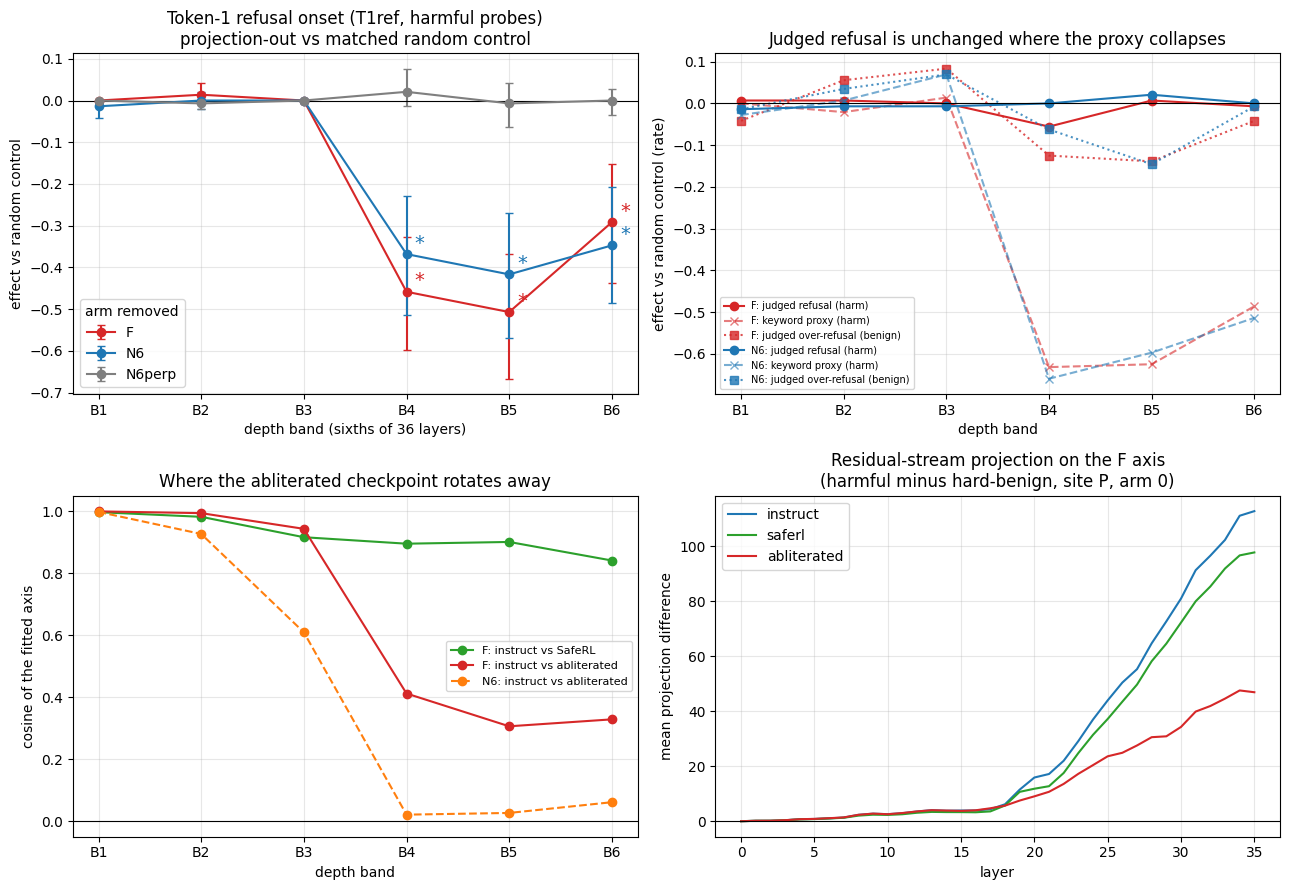

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
x = np.arange(len(BANDS))

# (1) recomputed forward-only effect on token-1 refusal onset
ax = axes[0, 0]
for arm, c in [("F", "tab:red"), ("N6", "tab:blue"), ("N6perp", "tab:gray")]:
    cells = grid["T1ref"]["harm"].get(arm, {})
    eff = [cells[b]["effect_vsR"]["effect"] if b in cells else np.nan for b in BANDS]
    lo = [cells[b]["effect_vsR"]["ci_lo"] if b in cells else np.nan for b in BANDS]
    hi = [cells[b]["effect_vsR"]["ci_hi"] if b in cells else np.nan for b in BANDS]
    eff, lo, hi = map(np.array, (eff, lo, hi))
    ax.errorbar(x, eff, yerr=[eff - lo, hi - eff], marker="o", capsize=3, color=c, label=arm)
    for i, b in enumerate(BANDS):
        if b in cells and cells[b].get("CAUSAL"):
            ax.annotate("*", (x[i], eff[i]), textcoords="offset points", xytext=(6, 4),
                        color=c, fontsize=14)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(BANDS)
ax.set_title("Token-1 refusal onset (T1ref, harmful probes)\nprojection-out vs matched random control")
ax.set_xlabel("depth band (sixths of 36 layers)"); ax.set_ylabel("effect vs random control")
ax.legend(title="arm removed"); ax.grid(alpha=0.3)

# (2) judged outcomes for the same cells
ax = axes[0, 1]
for arm, c in [("F", "tab:red"), ("N6", "tab:blue")]:
    rows = {e["band"]: e["judged"] for e in data["examples"]
            if e["arm"] == arm and e.get("judged")}
    ref = [rows[b]["refused_harm"]["effect_TR"][0] if b in rows else np.nan for b in BANDS]
    over = [rows[b]["over_refusal_hb"]["effect_TR"][0] if b in rows else np.nan for b in BANDS]
    prox = [rows[b].get("proxy_refused_harm_effect_TR", np.nan)
            if b in rows else np.nan for b in BANDS]
    ax.plot(x, ref, marker="o", color=c, label=f"{arm}: judged refusal (harm)")
    ax.plot(x, prox, marker="x", ls="--", color=c, alpha=0.6, label=f"{arm}: keyword proxy (harm)")
    ax.plot(x, over, marker="s", ls=":", color=c, alpha=0.8, label=f"{arm}: judged over-refusal (benign)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(BANDS)
ax.set_title("Judged refusal is unchanged where the proxy collapses")
ax.set_xlabel("depth band"); ax.set_ylabel("effect vs random control (rate)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (3) cross-model direction cosines
ax = axes[1, 0]
series = [("cos_F_instruct_vs_saferl_by_band", "F: instruct vs SafeRL", "tab:green", "-"),
          ("cos_F_instruct_vs_abliterated_by_band", "F: instruct vs abliterated", "tab:red", "-"),
          ("cos_N6_instruct_vs_abliterated_by_band", "N6: instruct vs abliterated", "tab:orange", "--")]
for key, lab, c, ls in series:
    ax.plot(x, [cos[key][b] for b in BANDS], marker="o", color=c, ls=ls, label=lab)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(BANDS); ax.set_ylim(-0.05, 1.05)
ax.set_title("Where the abliterated checkpoint rotates away")
ax.set_xlabel("depth band"); ax.set_ylabel("cosine of the fitted axis")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (4) per-layer activation separation on the F axis
ax = axes[1, 1]
for m, c in [("instruct", "tab:blue"), ("saferl", "tab:green"), ("abliterated", "tab:red")]:
    p = prof[m]
    harm = np.array(p["harm_mean"], dtype=float)
    ben = np.array(p["benign_mean"], dtype=float)
    ax.plot(np.arange(p["layers"]), harm[:, 0] - ben[:, 0], color=c, label=m)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Residual-stream projection on the F axis\n(harmful minus hard-benign, site P, arm 0)")
ax.set_xlabel("layer"); ax.set_ylabel("mean projection difference")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

- The **forward-only readout** is causally movable: removing the request axis `F` at the last prompt
  token in the deep bands shifts token-1 refusal-onset mass, and the effect clears matched random
  controls and Holm correction over the six bands.
- The **judged behaviour is not**. Zero cells are CAUSAL for judged refusal of harmful requests; the
  keyword proxy disagrees loudly, which is exactly why a text-level proxy cannot stand in for a judge.
  Refusal at the prompt token is positionally redundant — the model reconstructs it downstream.
- The one judged lever that is site-local is **over-refusal of hard-benign prompts**, which falls at the
  middle bands.
- At the activation level, instruct and SafeRL share their safety geometry; the abliterated checkpoint
  keeps the early layers intact and rotates from B4 on. Safety, in these checkpoints, does not live in a
  single place that a first-token readout can certify.